# Introduction to Temperature-based Climate Indices

> [!NOTE]
> The data shown in this repository is for **demonstration purposes only**. To obtain the full datasets for professional analysis, please use the official channels.

This notebook demonstrates how to compute and visualize **temperature-based climate indices** from CMIP6 datasets using the `earthkit-climate` and `xclim` packages.

We'll use:
- **Temperature-based indices**:
  - *DTR*: Daily Temperature Range (Tmax - Tmin)
  - *WSDI*: Warm Spell Duration Index (≥6 consecutive days above 90th percentile)
  - *HDD*: Heating Degree Days (based on temperature below threshold)

We’ll load **ACCESS-CM2 CMIP6 data** for both *historical* and *SSP585* scenarios.

In [1]:
import warnings

import cartopy.crs as ccrs
import earthkit.data as ekd
import earthkit.plots as ekp
import matplotlib.pyplot as plt

from earthkit.climate.indicators.temperature import (
    daily_temperature_range,
    heating_degree_days_approximation,
    warm_spell_duration_index,
)
from earthkit.climate.utils.percentile import calculate_percentile_doy

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)

## Loading CMIP6 data

We’ll use *daily gridded data* from the ACCESS-CM2 model for maximum (`tasmax`) and minimum (`tasmin`) temperature, for both historical and SSP585 future scenarios.


In [2]:
# Load temperature
tasmin_hist = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-climate/tasmin_ACCESS-CM2_historical_reference.nc",
)
tasmin_ssp585 = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-climate/tasmin_ACCESS-CM2_ssp585_far_future.nc",
)

tasmax_hist = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-climate/tasmax_ACCESS-CM2_historical_reference.nc",
)
tasmax_ssp585 = ekd.from_source(
    "url",
    "https://sites.ecmwf.int/repository/earthkit-climate/tasmax_ACCESS-CM2_ssp585_far_future.nc",
)

## Inspect and visualize the raw data

Before computing indices, let’s plot a few example grids to see how the raw variables look.


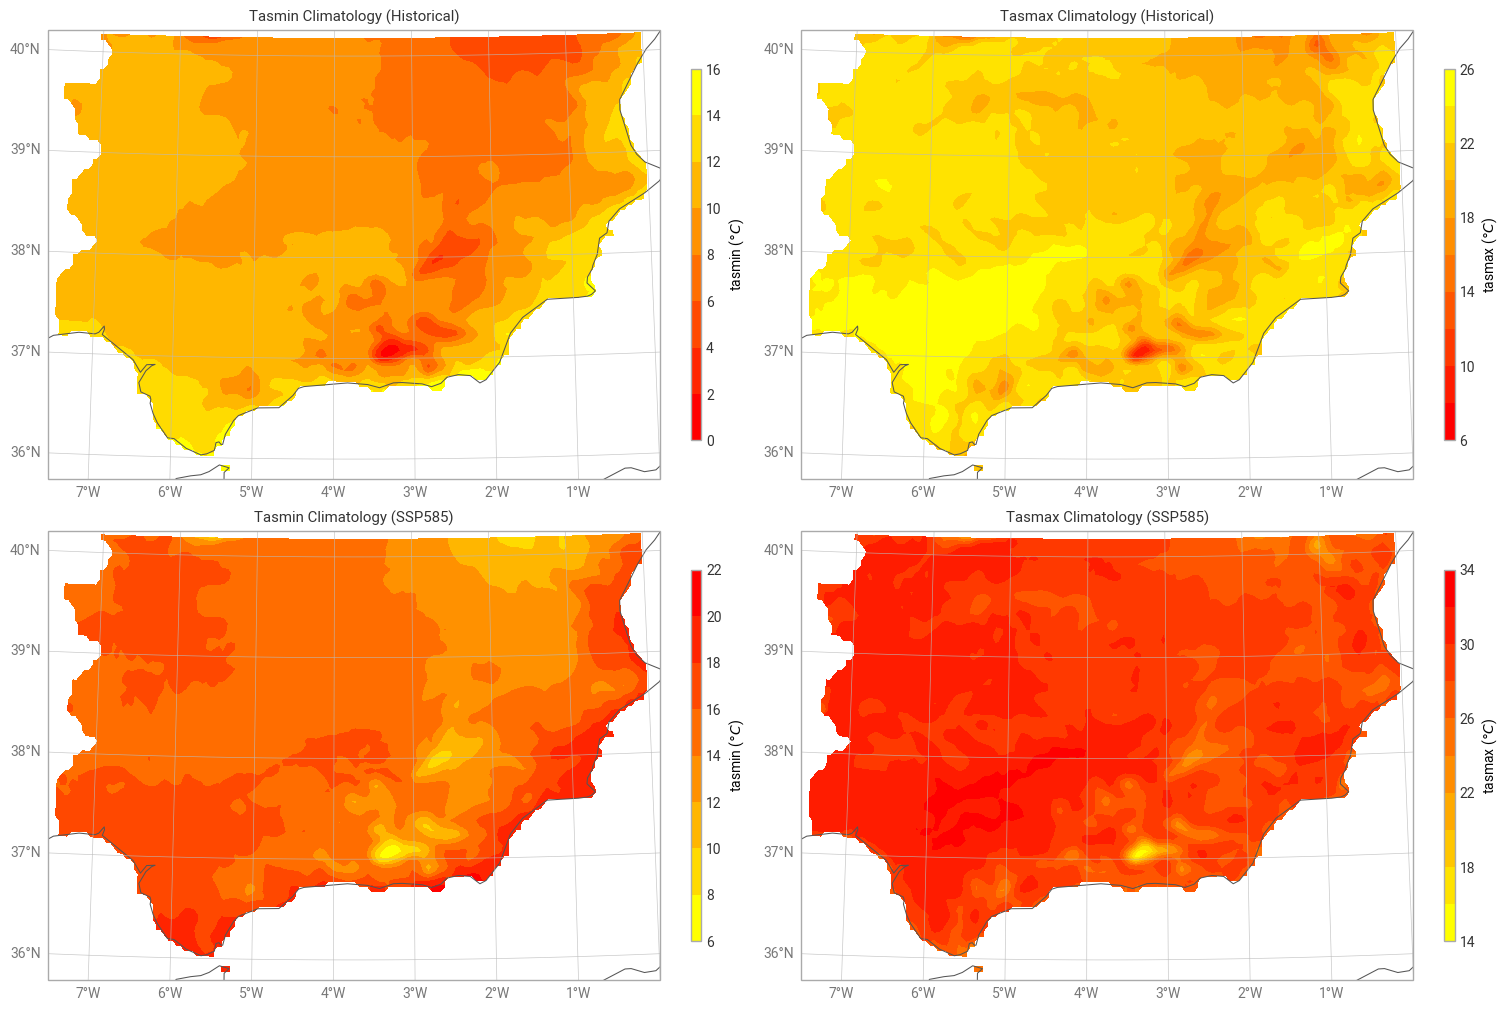

In [3]:
# Define domain (Southern Spain)
domain = [-7.5, 0, 35.8, 40.2]

# Create the figure with 2x3 maps
figure = ekp.Figure(
    crs=ccrs.NearsidePerspective(central_longitude=-3.75, central_latitude=38.0),
    rows=2,
    columns=2,
    size=(15, 10)
)

# Define variables and their datasets
variables = {
    "tasmin": (tasmin_hist, tasmin_ssp585, "celsius"),
    "tasmax": (tasmax_hist, tasmax_ssp585, "celsius"),
}

# HISTORICAL (row 0)
for col, (var, (hist, ssp, units)) in enumerate(variables.items()):
    hist_clim = hist.to_xarray().mean("time")
    cmap = "autumn"
    style = ekp.styles.Style(colors=cmap, units=units)
    map_plot = figure.add_map(row=0, column=col, domain=domain)
    map_plot.quickplot(hist_clim, style=style)
    map_plot.coastlines()
    map_plot.gridlines()
    map_plot.legend(location="right")
    map_plot.title(f"{var} Climatology (Historical)")

# SSP585 (row 1)
for col, (var, (hist, ssp, units)) in enumerate(variables.items()):
    ssp_clim = ssp.to_xarray().mean("time")
    cmap = "autumn_r"
    style = ekp.styles.Style(colors=cmap, units=units)
    map_plot = figure.add_map(row=1, column=col, domain=domain)
    map_plot.quickplot(ssp_clim, style=style)
    map_plot.coastlines()
    map_plot.gridlines()
    map_plot.legend(location="right")
    map_plot.title(f"{var} Climatology (SSP585)")

# Final layout
figure.show()

## Compute Daily Temperature Range (DTR)

**DTR** is simply the difference between the daily maximum and minimum temperature. We'll compute it for the SSP585 scenario.


In [4]:
dtr = daily_temperature_range(tasmax=tasmax_ssp585.to_xarray(), tasmin=tasmin_ssp585.to_xarray())
dtr

<xarray.DataArray 'dtr' (time: 30, lat: 88, lon: 150)> Size: 2MB
dask.array<where, shape=(30, 88, 150), dtype=float32, chunksize=(3, 40, 40), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2071-01-01 2072-01-01 ... 2100-01-01
  * lat      (lat) float64 704B 35.82 35.87 35.92 35.97 ... 40.07 40.12 40.17
  * lon      (lon) float64 1kB -7.475 -7.425 -7.375 ... -0.125 -0.075 -0.025
    height   float64 8B 2.0
Attributes:
    units:           K
    units_metadata:  temperature: difference
    cell_methods:     time range within days time: mean over days
    history:         [2026-03-11 14:57:12] dtr: DTR(tasmin=tasmin, tasmax=tas...
    standard_name:   air_temperature
    long_name:       Mean diurnal temperature range
    description:     Annual mean diurnal temperature range.

## Compute Warm Spell Duration Index (WSDI)

**WSDI** identifies periods of at least 6 consecutive days where the daily maximum temperature exceeds the 90th percentile of the historical reference period (calculated per day of year).


In [6]:
# WSDI (using historical baseline)
# Calculate 90th percentile from historical data
tasmax_per = calculate_percentile_doy(tasmax_hist.to_xarray(), variable="tasmax", percentile=90)

# Merge percentile with target dataset
ds_merged = tasmax_ssp585.to_xarray().merge(tasmax_per)

wsdi = warm_spell_duration_index(ds=ds_merged)

wsdi

<xarray.DataArray 'warm_spell_duration_index' (time: 30, lat: 88, lon: 150)> Size: 3MB
dask.array<where, shape=(30, 88, 150), dtype=float64, chunksize=(1, 14, 15), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2071-01-01 2072-01-01 ... 2100-01-01
  * lat      (lat) float64 704B 35.82 35.87 35.92 35.97 ... 40.07 40.12 40.17
  * lon      (lon) float64 1kB -7.475 -7.425 -7.375 ... -0.125 -0.075 -0.025
    height   float64 8B 2.0
Attributes:
    units:          days
    cell_methods:    time: sum over days
    history:        [2026-03-11 14:57:23] warm_spell_duration_index: WARM_SPE...
    standard_name:  number_of_days_with_air_temperature_above_threshold
    long_name:      Number of days with at least 6 consecutive days where the...
    description:    Annual number of days with at least 6 consecutive days wh...

## Compute Heating Degree Days (HDD)

**HDD** is the annual cumulative sum of temperature degrees for daily mean temperatures below a threshold (commonly 17.0°C). This version uses an approximation based on Tmin and Tmax.


In [7]:
tas_da = (tasmax_ssp585.to_xarray()["tasmax"] + tasmin_ssp585.to_xarray()["tasmin"]) / 2

hdd = heating_degree_days_approximation(
    tasmax_ssp585.to_xarray().tasmax,
    tasmin=tasmin_ssp585.to_xarray().tasmin,
    tas=tas_da,
)
hdd

<xarray.DataArray 'heating_degree_days_approximation' (time: 30, lat: 88,
                                                       lon: 150)> Size: 2MB
dask.array<where, shape=(30, 88, 150), dtype=float32, chunksize=(3, 40, 40), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 240B 2071-01-01 2072-01-01 ... 2100-01-01
  * lat      (lat) float64 704B 35.82 35.87 35.92 35.97 ... 40.07 40.12 40.17
  * lon      (lon) float64 1kB -7.475 -7.425 -7.375 ... -0.125 -0.075 -0.025
    height   float64 8B 2.0
Attributes:
    units:           K days
    units_metadata:  temperature: difference
    cell_methods:     time: sum over days
    history:         [2026-03-11 14:57:25] heating_degree_days_approximation:...
    standard_name:   integral_of_air_temperature_deficit_wrt_time
    long_name:       Cumulative sum of temperature degrees for daily temperat...
    description:     Annual cumulative heating degree days (temperature below...

## Visualization of Temperature Indices

Finally, let's visualize the climatologies of these temperature indices across our domain.


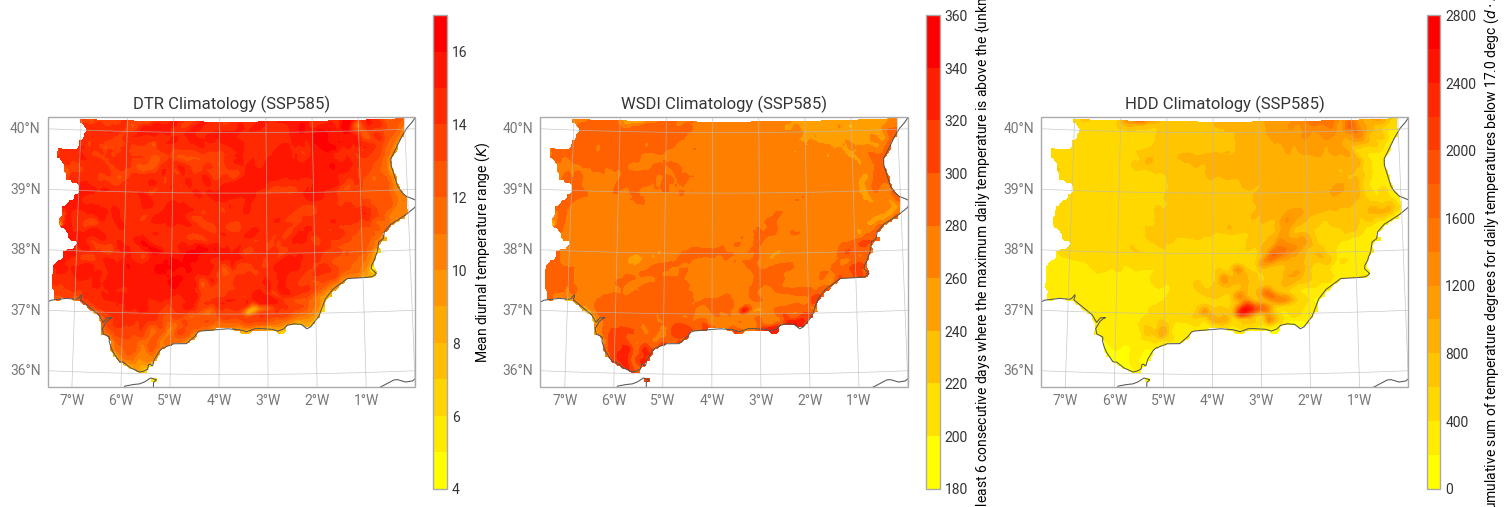

In [9]:
# Define domain (Southern Spain)
domain = [-7.5, 0, 35.8, 40.2]

# Create the figure with 2x3 maps
figure = ekp.Figure(
    crs=ccrs.NearsidePerspective(central_longitude=-3.75, central_latitude=38.0),
    rows=1,
    columns=3,
    size=(15, 6)
)

# Define indices and corresponding datasets
indices = {"DTR": dtr, "WSDI": wsdi, "HDD": hdd}
cmaps = {"DTR": "autumn_r", "WSDI": "autumn_r", "HDD": "autumn_r"}
units = {"DTR": "K", "WSDI": "days", "HDD": "K days"}

# PLOT: Each index climatology
for col, (name, index_obj) in enumerate(indices.items()):
    ds = index_obj.mean("time")
    cmap = cmaps[name]

    style = ekp.styles.Style(colors=cmap, units=units[name])
    map_plot = figure.add_map(row=0, column=col, domain=domain)
    map_plot.quickplot(ds, style=style)
    map_plot.coastlines()
    map_plot.gridlines()
    map_plot.title(f"{name} Climatology (SSP585)")
    map_plot.legend(location="right")

figure.show()